In [1]:
# input
zn_kinetec_file = "./data/rpia_enzyme_kinetic_zn.tsv"
mg_kinetec_file = "./data/rpia_enzyme_kinetic_mg.tsv"

# output
zn_fig_file  = "./fig/rpia_kinetic_curve_zn.pdf"
mg_fig_file  = "./fig/rpia_kinetic_curve_mg.pdf"

### Zn

In [2]:
import pandas as pd

df = pd.read_csv(zn_kinetec_file, sep='\t') 
df

,time,Blank,Apo,Zn_1_μM,Zn_5_μM,rep
0,0.0,0,0.00000,0.00000,0.00000,0
1,0.5,0,5.00000,8.75000,10.00000,0
2,1.0,0,10.00000,17.50000,18.75000,0
3,1.5,0,15.00000,26.25000,27.50000,0
4,2.0,0,18.75000,32.50000,35.00000,0
...,...,...,...,...,...,...
100,8.0,0,58.73016,80.95238,77.77778,4
101,8.5,0,61.90476,85.71429,80.95238,4
102,9.0,0,63.49206,88.88889,84.12698,4
103,9.5,0,68.25397,92.06349,87.30159,4


<ErrorbarContainer object of 3 artists>

<ErrorbarContainer object of 3 artists>

<ErrorbarContainer object of 3 artists>

<ErrorbarContainer object of 3 artists>

Text(0.5, 0, 'Time (min)')

Text(0, 0.5, 'Relative intensity of A280(%)')

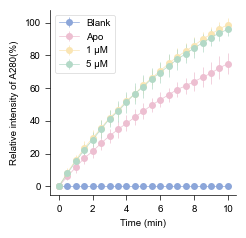

In [3]:

import matplotlib.pyplot as plt

plt.style.use(f"{PROJECT_DIR}/asset/metalnet.mplstyle")

grouped = df.groupby('time').agg(['mean', 'std'])

fig, ax = plt.subplots(figsize=(2.4, 2.4))
conditions = ['Blank', 'Apo', '1 μM', '5 μM'] # apo: EDTA condition

for i, col in enumerate(conditions):
    if col.endswith("μM"):
        df_col = "_".join(["Zn"] + col.split())
    else:
        df_col = col

    mean_val = grouped[df_col]['mean']
    std_val = grouped[df_col]['std']
    time = mean_val.index
    plt.errorbar(
        time, 
        mean_val, 
        yerr=std_val, 
        label=col, 
        # capsize=3, 
        fmt='-o', 
        markersize=4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel('Time (min)')
plt.ylabel('Relative intensity of A280(%)')
plt.legend(loc='upper left', bbox_to_anchor=(0, 1))
plt.savefig(zn_fig_file, transparent=True, bbox_inches='tight')


### Mg

In [4]:
import pandas as pd

df = pd.read_csv(mg_kinetec_file, sep='\t') 
df

,time,Apo,Mg_1_μM,Mg_5_μM,rep
0,0.0,0.000000,0.000000,0.000000,1
1,0.5,6.849315,6.849315,6.849315,1
2,1.0,12.328770,15.068490,15.068490,1
3,1.5,19.178080,21.917810,20.547950,1
4,2.0,24.657530,28.767120,27.397260,1
...,...,...,...,...,...
58,8.0,71.232880,80.821920,80.821920,3
59,8.5,73.972600,83.561640,84.931510,3
60,9.0,76.712330,87.671230,87.671230,3
61,9.5,79.452050,90.410960,90.410960,3


<ErrorbarContainer object of 3 artists>

<ErrorbarContainer object of 3 artists>

<ErrorbarContainer object of 3 artists>

Text(0.5, 0, 'Time (min)')

Text(0, 0.5, 'Relative intensity of A280(%)')

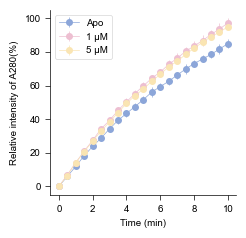

In [5]:

import matplotlib.pyplot as plt

plt.style.use(f"{PROJECT_DIR}/asset/metalnet.mplstyle")

grouped = df.groupby('time').agg(['mean', 'std'])

fig, ax = plt.subplots(figsize=(2.4, 2.4))
conditions = ['Apo', '1 μM', '5 μM'] # apo: EDTA condition

for i, col in enumerate(conditions):
    if col.endswith("μM"):
        df_col = "_".join(["Mg"] + col.split())
    else:
        df_col = col

    mean_val = grouped[df_col]['mean']
    std_val = grouped[df_col]['std']
    time = mean_val.index
    plt.errorbar(
        time, 
        mean_val, 
        yerr=std_val, 
        label=col, 
        # capsize=3, 
        fmt='-o', 
        markersize=4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel('Time (min)')
plt.ylabel('Relative intensity of A280(%)')
plt.legend(loc='upper left', bbox_to_anchor=(0, 1))
plt.savefig(mg_fig_file, transparent=True, bbox_inches='tight')
